# AA-UTE-2026

## Demo 0 - Visualización de series temporales 

Adaptado del contenido de "Forecasting: Principles and Practice, the Pythonic Way" [1]

[1] Hyndman, R.J., Athanasopoulos, G., Garza, A., Challu, C., Mergenthaler, M., & Olivares, K.G. (2026). Forecasting: Principles and Practice, the Pythonic Way. OTexts: Melbourne, Australia. Available at: OTexts.com/fpppy. Accessed on 1 July 2026.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series #as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])


mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

In [2]:
import statsmodels.api as sm
from scipy.stats import pearsonr
from statsmodels.graphics.tsaplots import plot_acf

## Datos de vuelos semanales de una aerolinea australiana

In [3]:
import pandas as pd
df =pd.read_csv("datos/fpppy/ansett.csv")


Ver sólo de vuelos entre Melbourne y Sydney en clase economy

3881    Economy
3882    Economy
3883    Economy
3884    Economy
3885    Economy
         ...   
4158    Economy
4159    Economy
4160    Economy
4161    Economy
4162    Economy
Name: Class, Length: 282, dtype: object


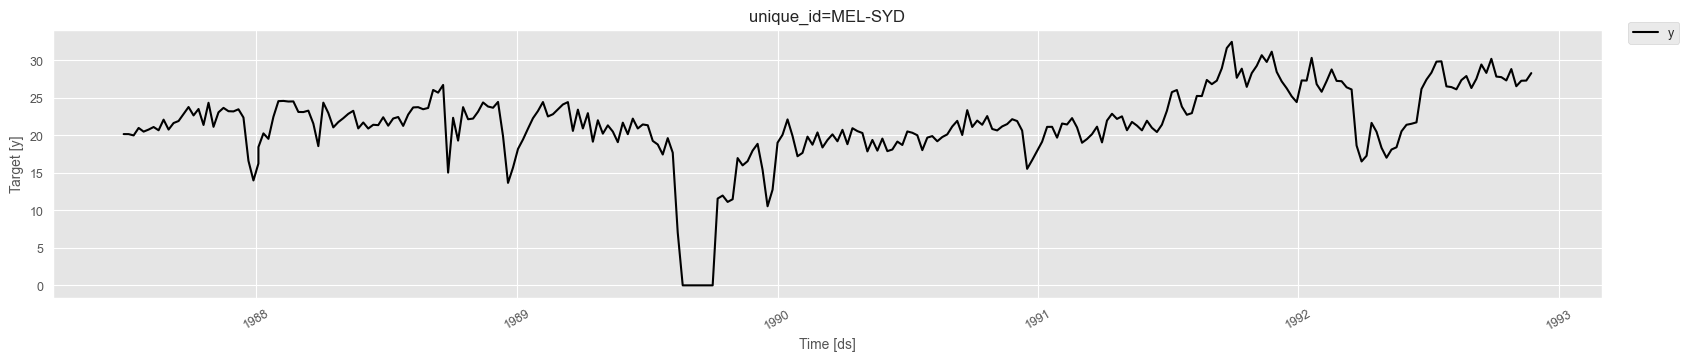

In [17]:
melsyd_economy = (
    pd.read_csv("datos/fpppy/ansett.csv", parse_dates=["ds"])    # se lee que la columna "ds" es de tipo fecha
    .loc[lambda x: (x["Airports"] == "MEL-SYD")                  # se filtra por la ruta MEL-SYD y clase Economy
        & (x["Class"] == "Economy")]                             
    .rename(columns={"Airports": "unique_id"})                   # se renombra la columna "Airports" a "unique_id"
    .assign(y=lambda x: x["y"] / 1000)                           # se convierte la columna "y" a miles
)
print(melsyd_economy.Class)
# Se usa plot_series de utilsforecast.plotting para graficar la serie de tiempo
plot_series(
    df=melsyd_economy, id_col="unique_id", time_col="ds", target_col="y",
    )

Ver los vuelos de todas las rutas en clase economy 

In [9]:
all_economy = (
    pd.read_csv("datos/fpppy/ansett.csv", parse_dates=["ds"])    # se lee que la columna "ds" es de tipo fecha
    .loc[lambda x:  (x["Class"] == "Economy")]                 # se filtra por la ruta clase Economy                                                        
    .rename(columns={"Airports": "unique_id"})                   # se renombra la columna "Airports" a "unique_id"
    .assign(y=lambda x: x["y"] / 1000)                           # se convierte la columna "y" a miles
)

all_economy

,ds,unique_id,Class,y
176,1987-06-29,ADL-PER,Economy,2.084
177,1987-07-06,ADL-PER,Economy,2.186
178,1987-07-13,ADL-PER,Economy,2.137
179,1987-07-20,ADL-PER,Economy,2.090
180,1987-07-27,ADL-PER,Economy,1.595
...,...,...,...,...
7120,1992-10-26,SYD-PER,Economy,4.294
7121,1992-11-02,SYD-PER,Economy,4.233
7122,1992-11-09,SYD-PER,Economy,4.577
7123,1992-11-16,SYD-PER,Economy,4.329


In [6]:
all_economy.unique_id.unique()

<ArrowStringArray>
['ADL-PER', 'MEL-ADL', 'MEL-BNE', 'MEL-OOL', 'MEL-PER', 'MEL-SYD', 'SYD-ADL',
 'SYD-BNE', 'SYD-OOL', 'SYD-PER']
Length: 10, dtype: str

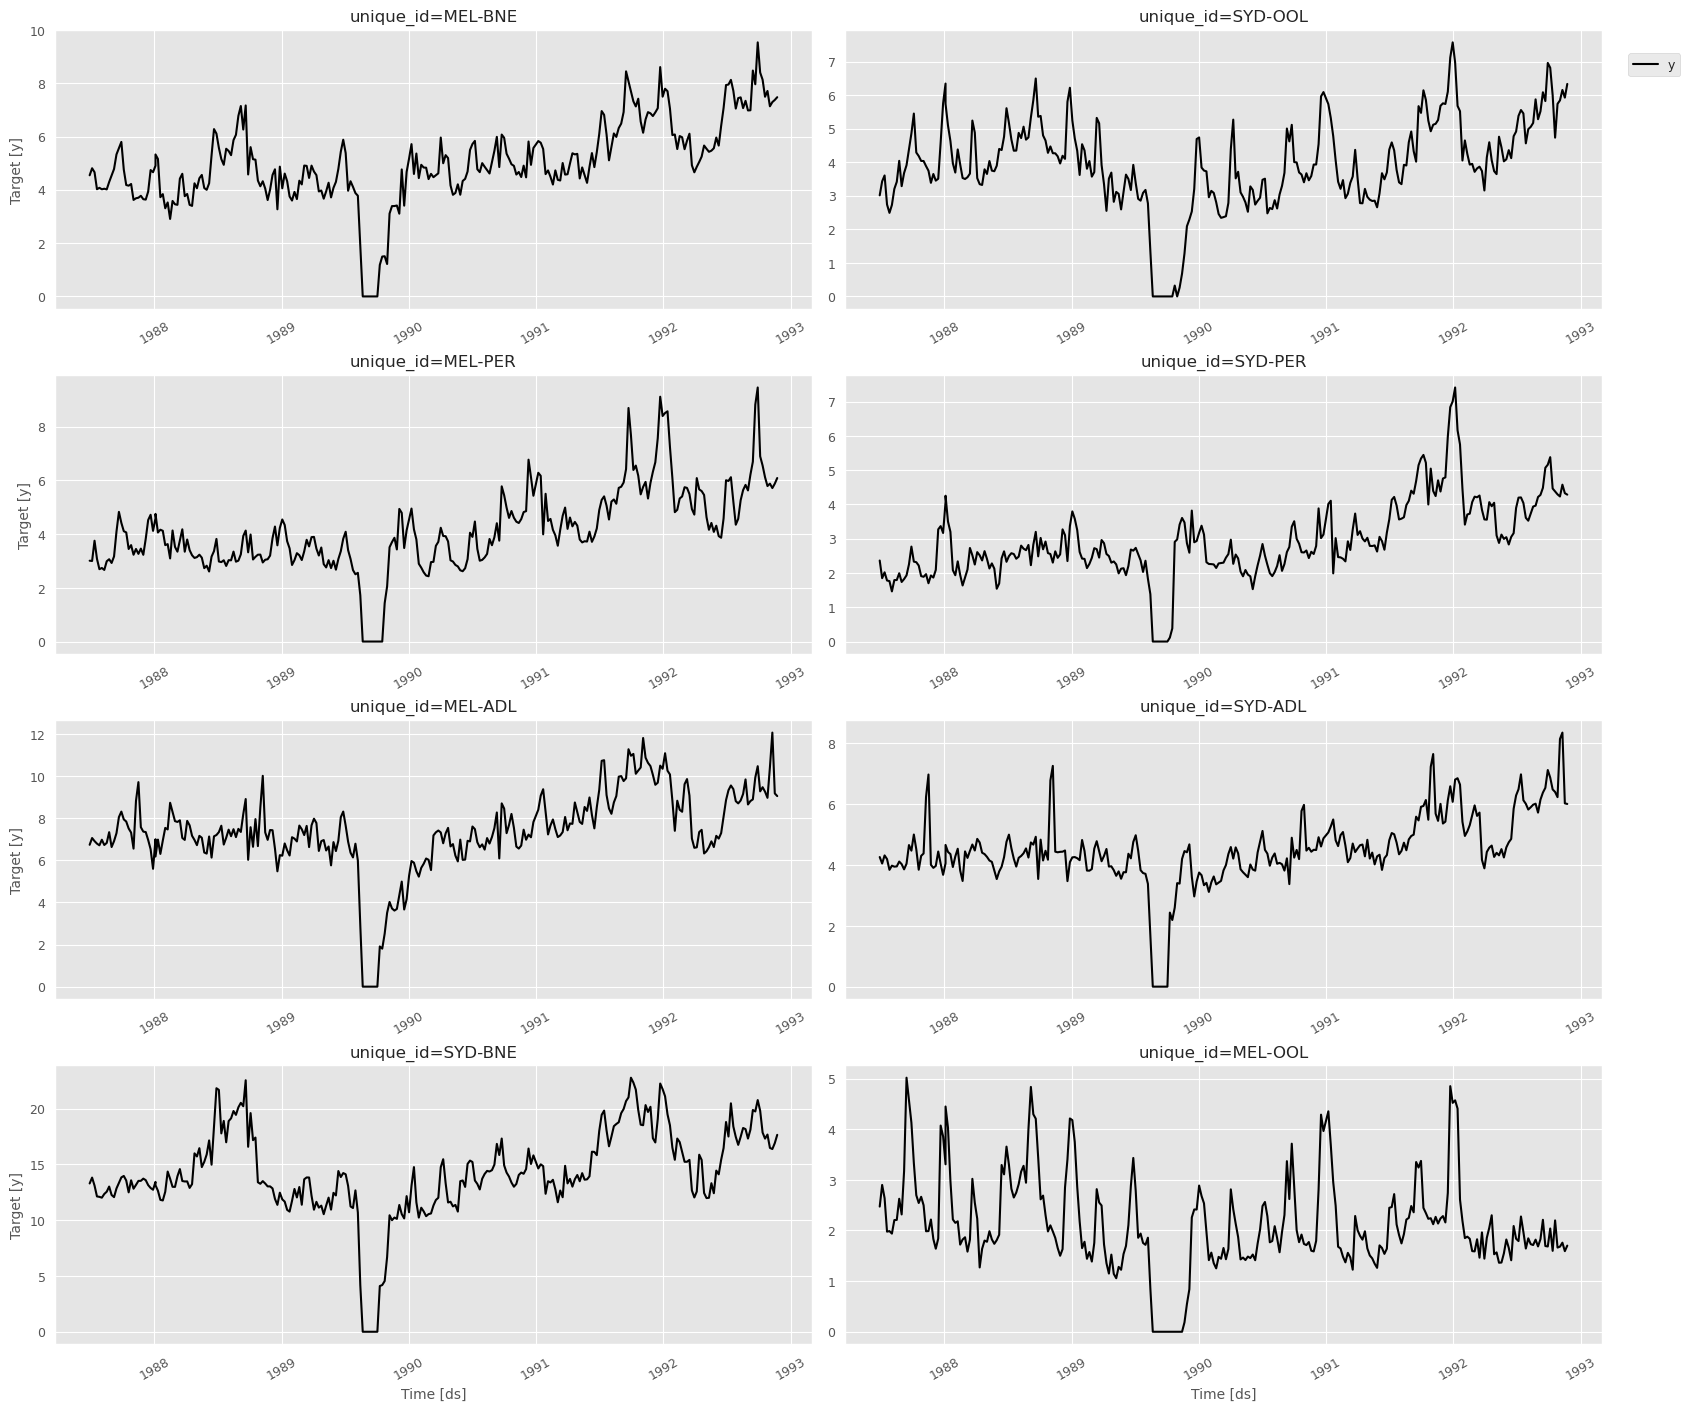

In [ ]:
plot_series(df=all_economy, id_col="unique_id", time_col="ds", target_col="y")

## Data farmaceutica

In [10]:
pbs = (
    pd.read_csv("datos/fpppy/PBS_unparsed.csv", parse_dates=["Month"])
    [["Month", "Concession", "Type", "ATC1", "ATC2", "Scripts", "Cost"]]
)
pbs

,Month,Concession,Type,ATC1,ATC2,Scripts,Cost
0,1991-07-01,Concessional,Co-payments,A,A01,18228,67877.0
1,1991-08-01,Concessional,Co-payments,A,A01,15327,57011.0
2,1991-09-01,Concessional,Co-payments,A,A01,14775,55020.0
3,1991-10-01,Concessional,Co-payments,A,A01,15380,57222.0
4,1991-11-01,Concessional,Co-payments,A,A01,14371,52120.0
...,...,...,...,...,...,...,...
67591,2008-02-01,General,Safety net,Z,Z,135,1591.0
67592,2008-03-01,General,Safety net,Z,Z,15,276.0
67593,2008-04-01,General,Safety net,Z,Z,11,165.0
67594,2008-05-01,General,Safety net,Z,Z,21,278.0


Qué se hace en la siguiente celda con el dataset "pbs" ?

filtra por el tipo de remedio o algo asi, 

luego elimina las columnas ATC ya que no interesan porque debido al filtro va a repetir la misma info

agrupa por mes

calcula la suma de la agrupacion 

lo divide entre 1.000.000 y lo asigna a la columna "Cost"


In [12]:
total_cost_df = (
    pbs.loc[pbs["ATC2"] == "A10"]
    .drop(columns=["ATC1", "ATC2"])
    .groupby("Month", as_index=False)
    .agg({"Cost": "sum"})
    .assign(Cost=lambda x: (x["Cost"] / 1e6).round(2))
)
total_cost_df

,Month,Cost
0,1991-07-01,3.53
1,1991-08-01,3.18
2,1991-09-01,3.25
3,1991-10-01,3.61
4,1991-11-01,3.57
...,...,...
199,2008-02-01,21.65
200,2008-03-01,18.26
201,2008-04-01,23.11
202,2008-05-01,22.91


Ejemplo de gráfico estacional - estacionalidad anual

       Month  Cost Month_name  Year  Month_num
0 1991-07-01  3.53       Jul.  1991          7
1 1991-08-01  3.18       Ago.  1991          8
2 1991-09-01  3.25       Set.  1991          9
3 1991-10-01  3.61       Oct.  1991         10
4 1991-11-01  3.57       Nov.  1991         11


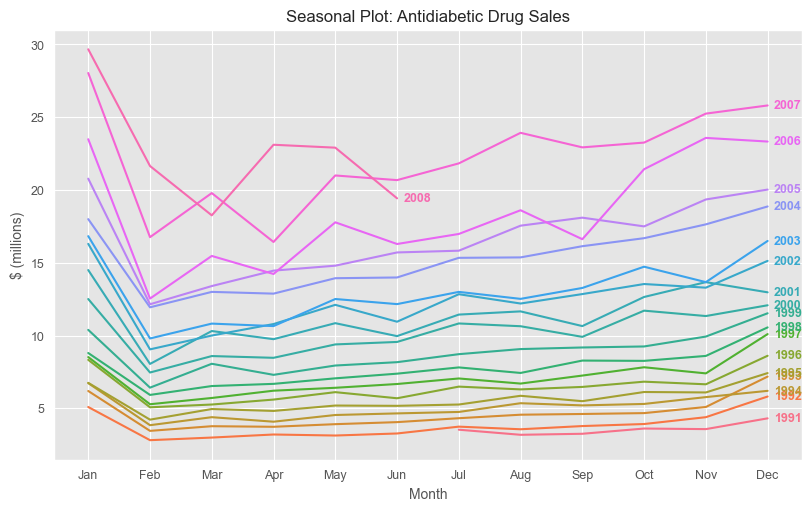

In [13]:
df = total_cost_df.assign(
    Month_name=total_cost_df["Month"].dt.strftime("%b"),
    Year=total_cost_df["Month"].dt.year,
    Month_num=total_cost_df["Month"].dt.month,
)
unique_years = df["Year"].unique()
year_palette = sns.color_palette("husl", n_colors=len(unique_years))
fig, ax = plt.subplots()
sns.lineplot(data=df, x="Month_num", y="Cost",
  hue="Year", palette=year_palette, legend=False, ax=ax)

ax.set(
    title="Seasonal Plot: Antidiabetic Drug Sales",
    xlabel="Month",
    ylabel="$ (millions)",
    xticks=range(1, 13),
    xticklabels=[
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
    ]
)
min_year = unique_years.min()
for year, subset in df.groupby("Year"):
    x = subset["Month_num"].iloc[-1] + .1
    y = subset["Cost"].iloc[-1]
    color = year_palette[year - min_year]
    ax.text(x, y, str(year),
        ha="left", va="center", fontsize=9, weight="bold", color=color)
print(df.head())    
fig.show()

## Demanda de electricidad del estado de Victoria, Australia


In [14]:
vic_elec_df = pd.read_csv("datos/fpppy/vic_elec.csv", parse_dates=["ds"])
vic_elec_demand = vic_elec_df[vic_elec_df["unique_id"] == "Demand"]
df = vic_elec_demand.assign(
    hour_minute=lambda x: x["ds"].dt.strftime("%H:%M"),
    day=lambda x: x["ds"].dt.date,
)
df

,ds,unique_id,y,Holiday,hour_minute,day
0,2012-01-01 00:00:00,Demand,4382.825,True,00:00,2012-01-01
1,2012-01-01 00:30:00,Demand,4263.366,True,00:30,2012-01-01
2,2012-01-01 01:00:00,Demand,4048.966,True,01:00,2012-01-01
3,2012-01-01 01:30:00,Demand,3877.563,True,01:30,2012-01-01
4,2012-01-01 02:00:00,Demand,4036.230,True,02:00,2012-01-01
...,...,...,...,...,...,...
52597,2014-12-31 21:30:00,Demand,3873.449,False,21:30,2014-12-31
52598,2014-12-31 22:00:00,Demand,3791.637,False,22:00,2014-12-31
52599,2014-12-31 22:30:00,Demand,3724.836,False,22:30,2014-12-31
52600,2014-12-31 23:00:00,Demand,3761.887,False,23:00,2014-12-31


Gráfico de toda la serie

In [15]:
plot_series(df, engine="plotly")

La serie tiene estacionalidad diaria, semanal y anual

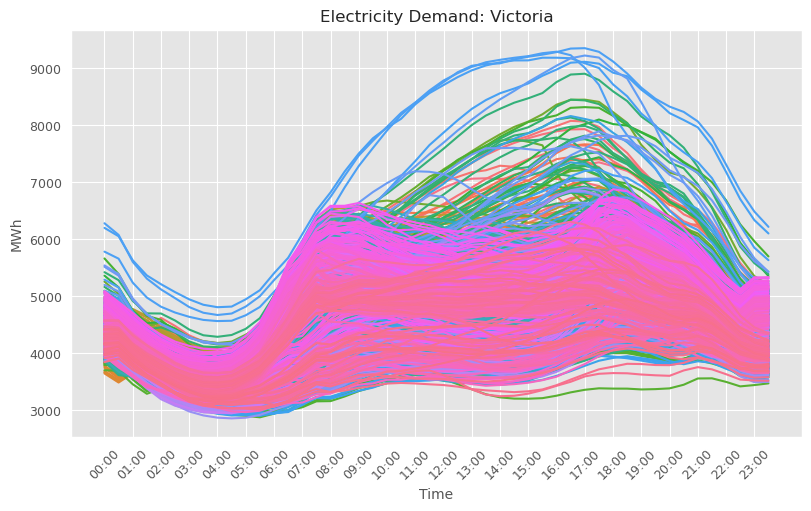

In [13]:

fig, ax = plt.subplots()
sns.lineplot(data=df, x="hour_minute", y="y",
    hue="day", palette="husl", legend=False, ax=ax)
ax.set(
    title="Electricity Demand: Victoria",
    xlabel="Time",
    ylabel="MWh",
)
unique_ticks = df["hour_minute"].unique()
ticks = range(0, len(unique_ticks), 2)
ticklabels = unique_ticks[::2]
ax.set_xticks(ticks, labels=ticklabels, rotation=45)
fig.show()

In [14]:
df = (
    vic_elec_demand
    .loc[lambda x: x["ds"].between("2012-01-02", "2014-12-28 23:59")]
    .assign(
        day_of_week=lambda x: x["ds"].dt.day_name(),
        week=lambda x: x["ds"].dt.to_period("W").dt.start_time,
    )
)
df


,ds,unique_id,y,Holiday,day_of_week,week
48,2012-01-02 00:00:00,Demand,4367.914,True,Monday,2012-01-02
49,2012-01-02 00:30:00,Demand,4164.016,True,Monday,2012-01-02
50,2012-01-02 01:00:00,Demand,3898.240,True,Monday,2012-01-02
51,2012-01-02 01:30:00,Demand,3752.017,True,Monday,2012-01-02
52,2012-01-02 02:00:00,Demand,3941.369,True,Monday,2012-01-02
...,...,...,...,...,...,...
52453,2014-12-28 21:30:00,Demand,4523.413,False,Sunday,2014-12-22
52454,2014-12-28 22:00:00,Demand,4343.926,False,Sunday,2014-12-22
52455,2014-12-28 22:30:00,Demand,4140.478,False,Sunday,2014-12-22
52456,2014-12-28 23:00:00,Demand,3998.337,False,Sunday,2014-12-22


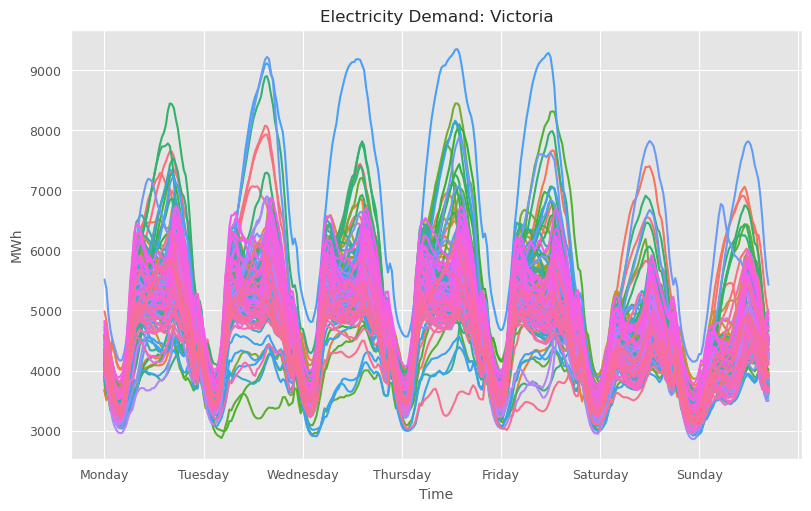

In [15]:


unique_weeks = df["week"].unique()
palette = sns.color_palette("husl", n_colors=len(unique_weeks))
color_map = dict(zip(unique_weeks, palette))

fig, ax = plt.subplots()
for week, df_week in df.groupby("week"):
    df_week.plot(x="day_of_week", y="y",
        ax=ax, color=color_map[week])
ax.get_legend().remove()
ax.set(
    title="Electricity Demand: Victoria",
    xlabel="Time",
    ylabel="MWh",
)
fig.show()

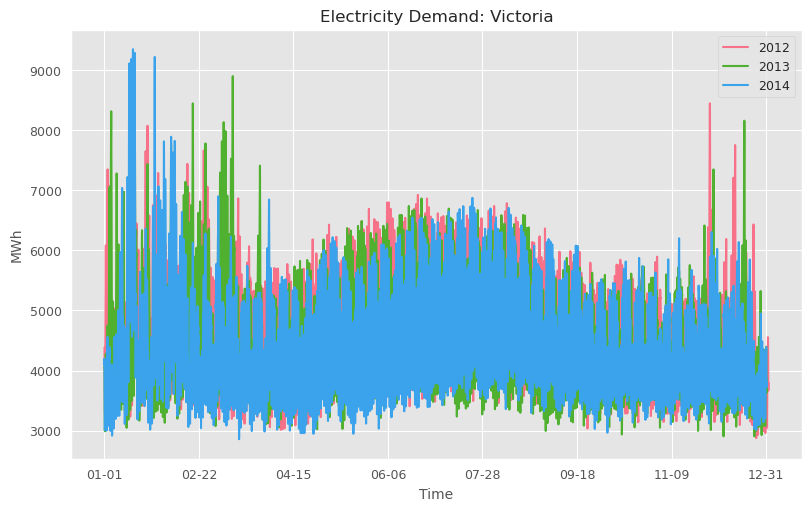

In [16]:
df = vic_elec_demand.assign(
    day_of_year=lambda x: x["ds"].dt.strftime("%m-%d"),
    year=lambda x: x["ds"].dt.year,
)

palette = sns.color_palette("husl", n_colors=df["year"].nunique())
fig, ax = plt.subplots()
for i_year, (year, df_year) in enumerate(df.groupby("year")):
    df_year.plot(x="day_of_year", y="y", ax=ax,
        label=str(year), color=palette[i_year])
ax.set(
    title="Electricity Demand: Victoria",
    ylabel="MWh",
    xlabel="Time",
)
fig.show()

## Afluencia de turistas a distintas ciudades de Australia

In [21]:
tourism = pd.read_csv("datos/fpppy/tourism.csv", parse_dates=["ds"])
trips = (
    tourism.loc[lambda x: x["Purpose"] == "Holiday"]
    .groupby(["State", "ds"], as_index=False)
    .agg({"y": "sum"})
)
trips

,State,ds,y
0,ACT,1998-01-01,196.219
1,ACT,1998-04-01,126.771
2,ACT,1998-07-01,110.680
3,ACT,1998-10-01,170.472
4,ACT,1999-01-01,107.779
...,...,...,...
635,Western Australia,2016-10-01,982.753
636,Western Australia,2017-01-01,1134.352
637,Western Australia,2017-04-01,997.852
638,Western Australia,2017-07-01,879.989


In [22]:
visitors = tourism.groupby(["State", "ds"], as_index=False)["y"].sum()
visitors

,State,ds,y
0,ACT,1998-01-01,551.002
1,ACT,1998-04-01,416.026
2,ACT,1998-07-01,436.029
3,ACT,1998-10-01,449.798
4,ACT,1999-01-01,378.573
...,...,...,...
635,Western Australia,2016-10-01,2656.331
636,Western Australia,2017-01-01,2570.912
637,Western Australia,2017-04-01,2438.488
638,Western Australia,2017-07-01,2493.955


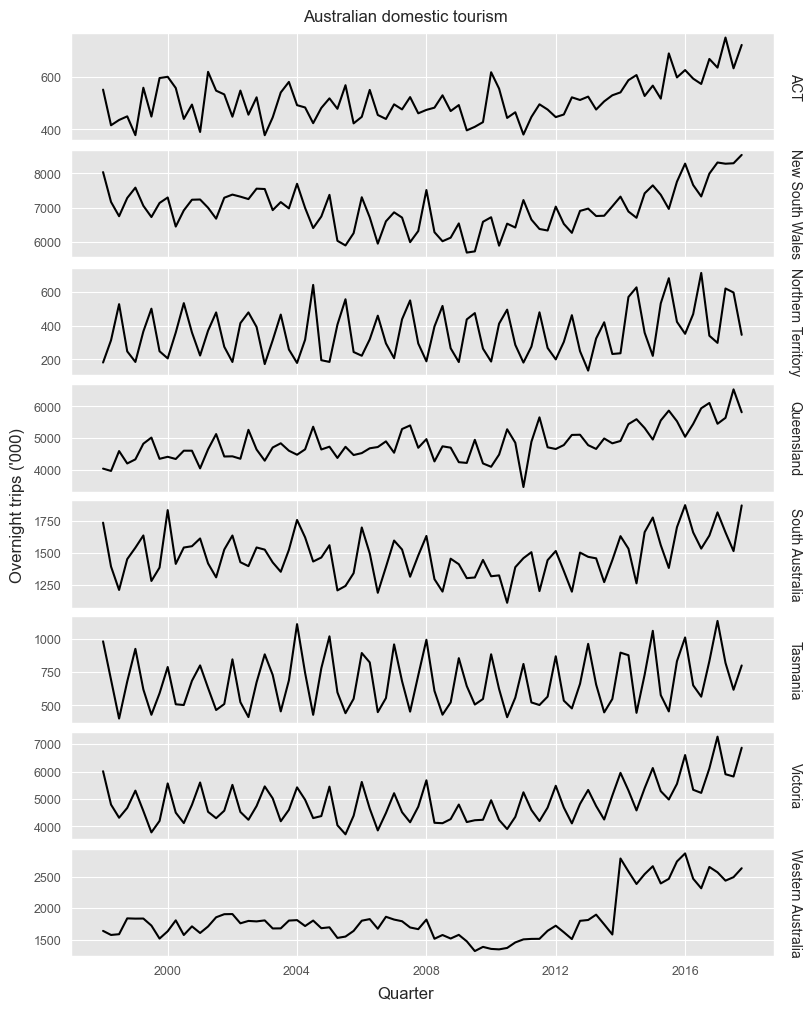

In [23]:

num_states = visitors["State"].nunique()
fig, axes = plt.subplots(num_states, 1, sharex=True, figsize=(8, 10))
for ax, (state, state_df) in zip(axes, visitors.groupby("State")):
    ax.plot(state_df["ds"], state_df["y"])
    ax.text(1.02, 0.5, state, va="center", ha="left",
        rotation=270, transform=ax.transAxes)
fig.suptitle("Australian domestic tourism")
fig.supxlabel("Quarter")
fig.supylabel("Overnight trips ('000)")
fig.show()

### Pasar de long format a wide format para tener una columna por cada estado

In [24]:
df = visitors.pivot(index="ds", columns="State", values="y")
df

State,ACT,New South Wales,Northern Territory,Queensland,South Australia,Tasmania,Victoria,Western Australia
ds,,,,,,,,
1998-01-01,551.002,8039.795,181.449,4041.370,1735.438,981.629,6010.424,1641.089
1998-04-01,416.026,7166.014,313.936,3967.905,1394.638,693.288,4795.247,1576.327
1998-07-01,436.029,6747.936,528.437,4593.894,1213.331,401.875,4316.845,1588.294
1998-10-01,449.798,7282.082,247.703,4202.829,1452.570,680.601,4674.829,1839.717
1999-01-01,378.573,7584.777,184.890,4332.491,1541.182,925.420,5304.334,1835.688
...,...,...,...,...,...,...,...,...
2016-10-01,667.214,7995.502,340.696,6106.384,1635.468,832.990,6113.016,2656.331
2017-01-01,634.369,8320.703,298.166,5451.987,1815.412,1135.313,7269.527,2570.912
2017-04-01,748.290,8285.026,621.441,5638.474,1660.132,820.369,5901.387,2438.488


### Ver correlaciones

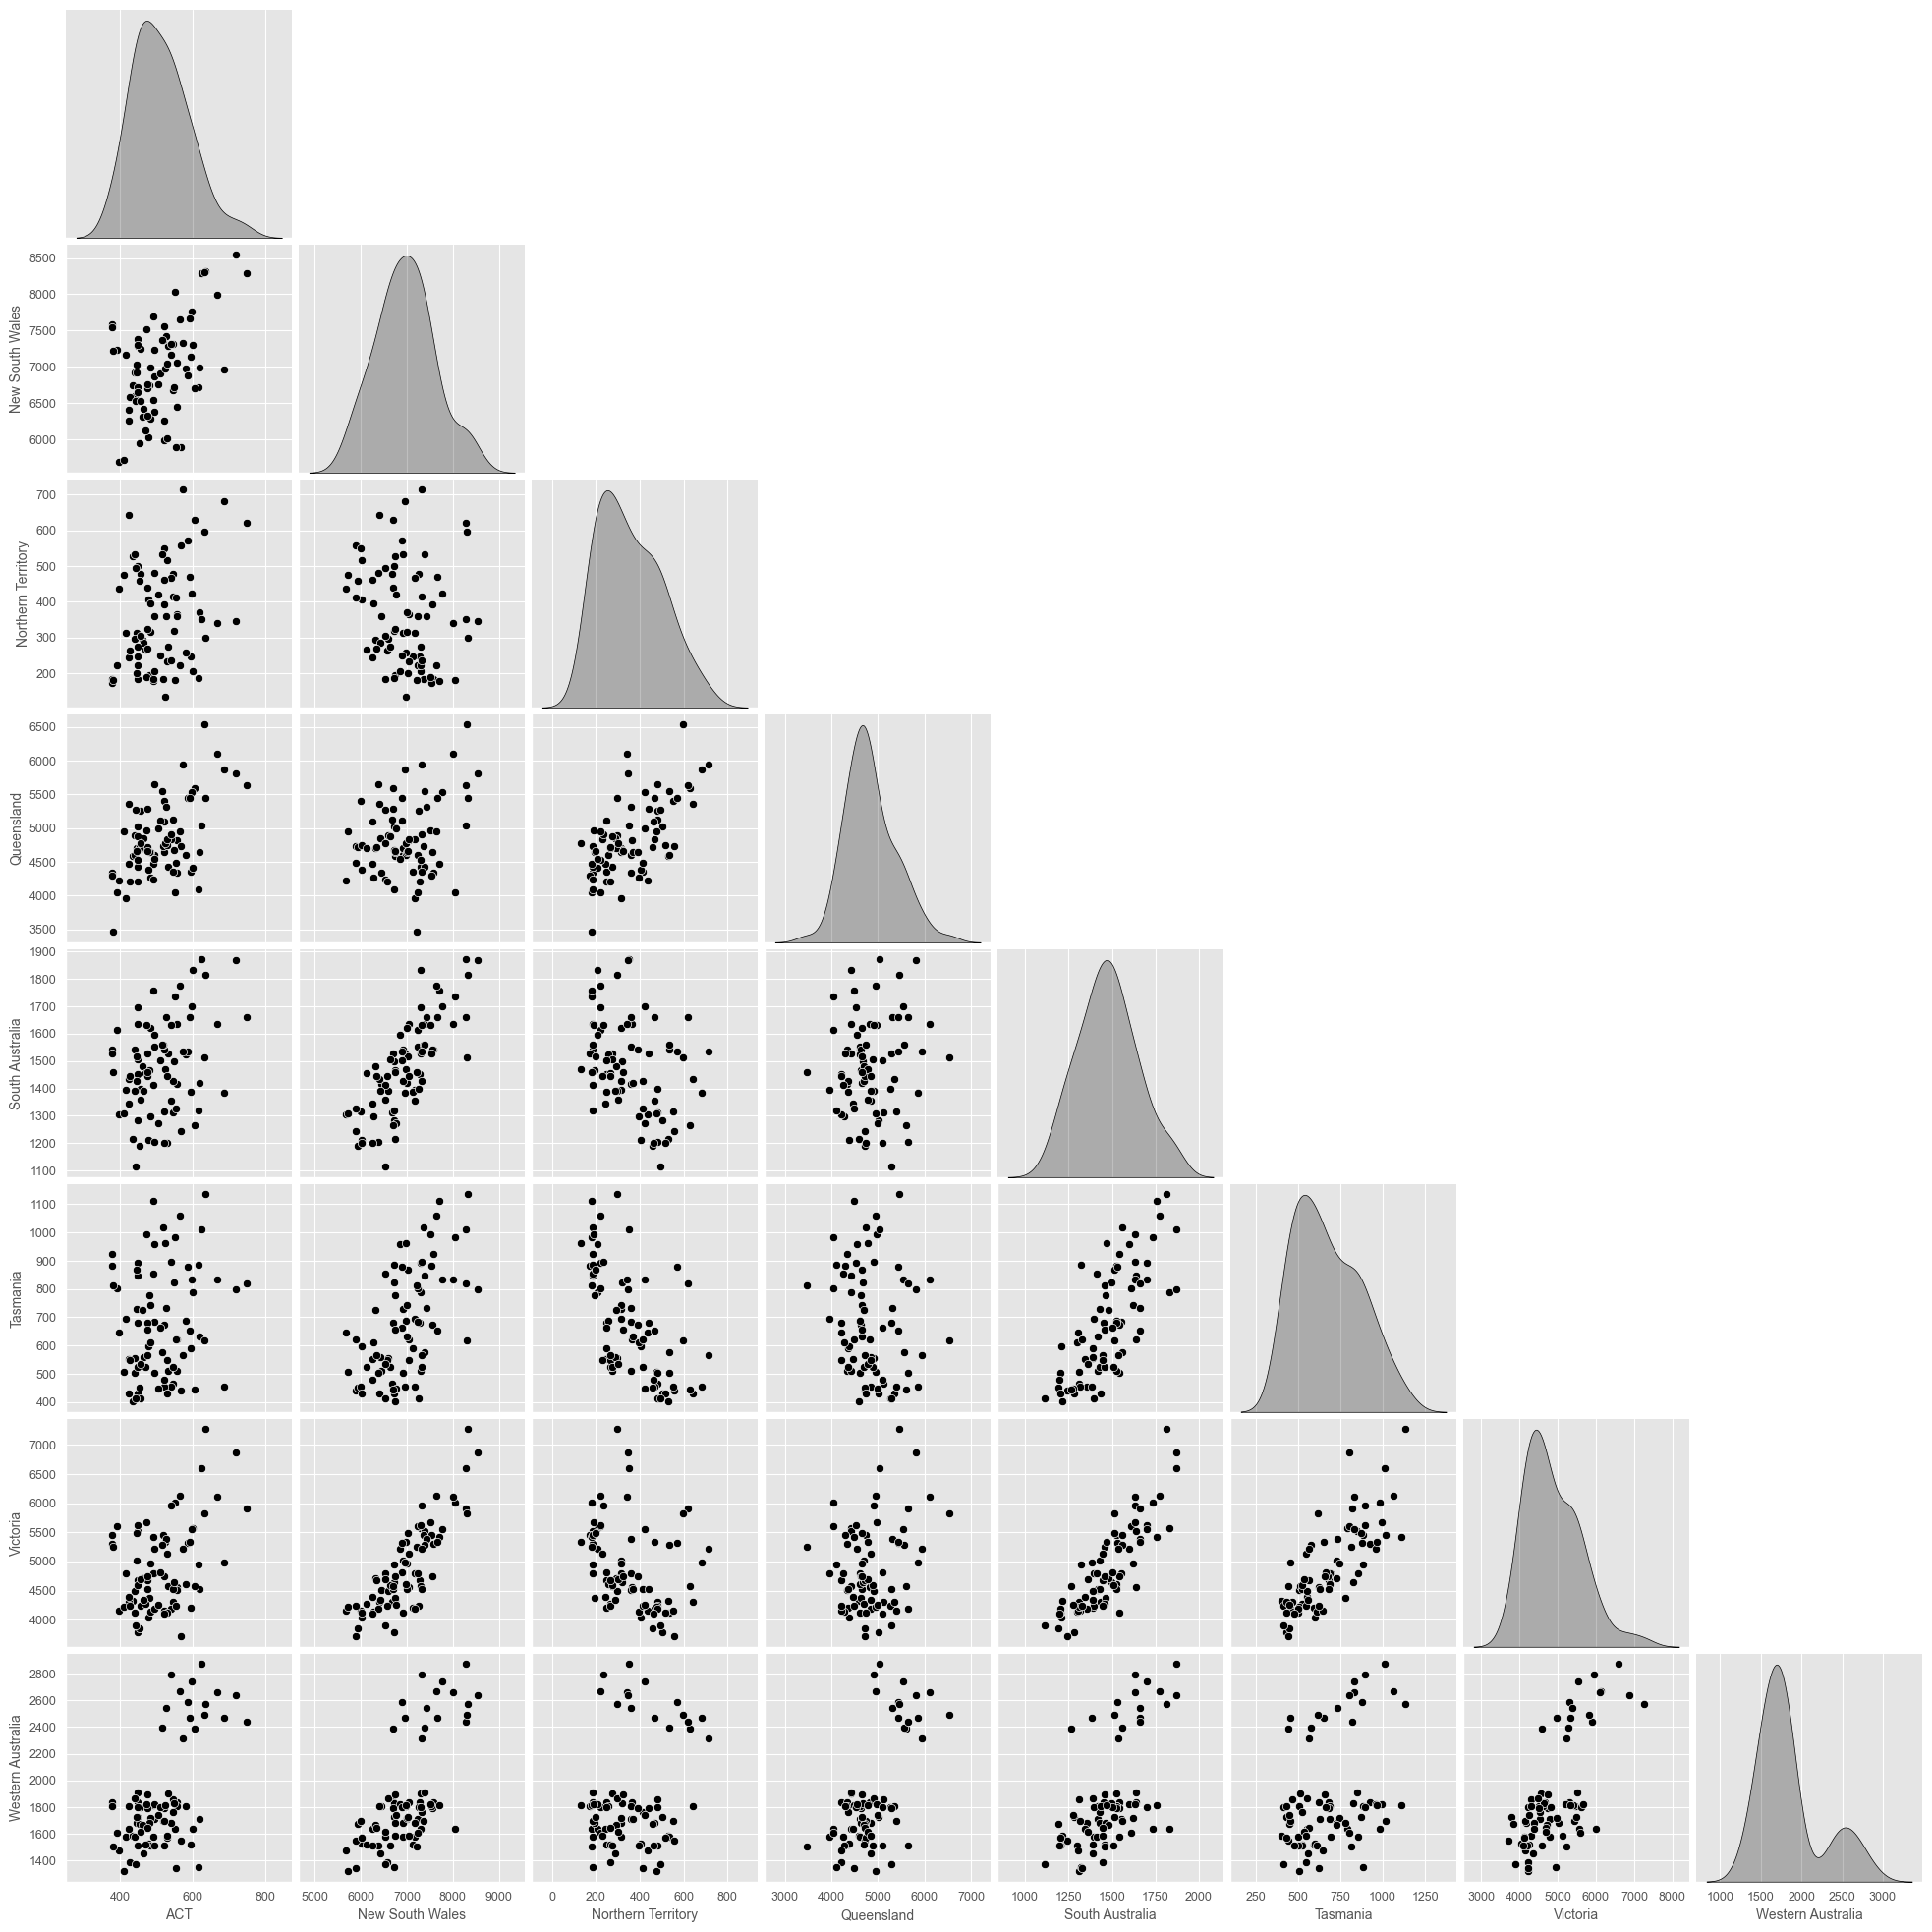

In [27]:
g = sns.pairplot(df, diag_kind="kde", corner=True)

<Axes: xlabel='State', ylabel='State'>

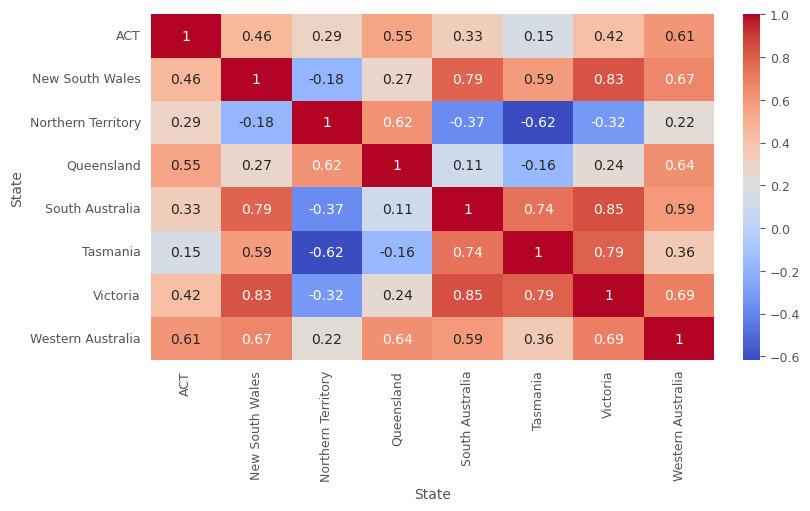

In [22]:
#matriz de correlación
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

### Gráficos de autocorrelación

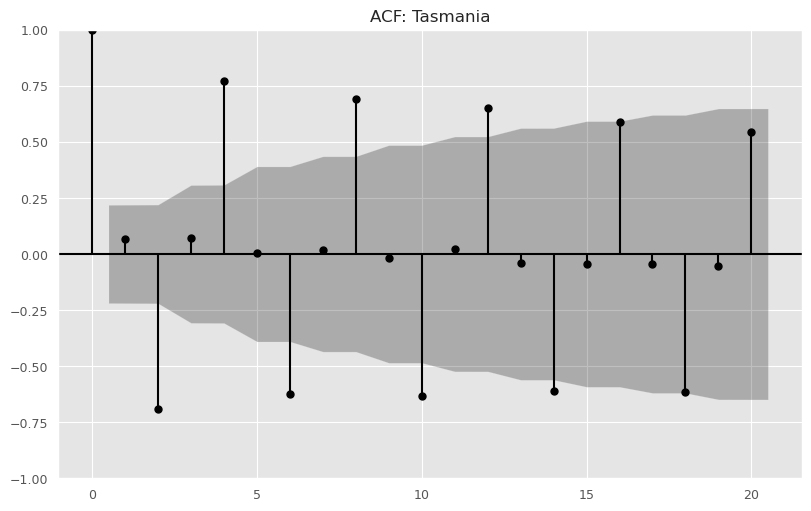

In [23]:
_ = plot_acf(df["Tasmania"], lags=20, title="ACF: Tasmania")